In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import scipy.stats as stats
import pyodbc

In [2]:
print(pyodbc.drivers())

['SQL Server', 'ODBC Driver 17 for SQL Server', 'Microsoft Access dBASE Driver (*.dbf, *.ndx, *.mdx)', 'SQL Server Native Client RDA 11.0', 'ODBC Driver 18 for SQL Server', 'MySQL ODBC 8.3 ANSI Driver', 'MySQL ODBC 8.3 Unicode Driver', 'PostgreSQL ANSI(x64)', 'PostgreSQL Unicode(x64)', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)']


In [3]:
connection = pyodbc.connect(driver='{ODBC Driver 17 for SQL Server}',server='DESKTOP-CB8O1S6',database='Universities_db',trusted_connection='yes')

In [4]:
df = pd.read_sql_query('Select * from [Top_Universities]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_4720\3549416611.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query('Select * from [Top_Universities]',con=connection)


In [5]:
df.head(10)

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000
5,6,Islamic Azad University,Iran,Asia,1982,Private,In-Person,1000000
6,7,"Laureate Education, Inc.",International,Global,1999,Private,Distance/In-Person,875000
7,8,Bangladesh Open University,"Gazipur, Bangladesh",Asia,1992,Public,Distance,650000
8,9,Universitas Terbuka,"Jakarta, Indonesia",Asia,1984,Public,Distance,646467
9,10,National Technological Institute of Mexico,Mexico,North America,1948 and 2014,Public,In-Person,620000


# EDA and Data Cleaning

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Rank                84 non-null     object
 1   Institution         84 non-null     object
 2   Location            84 non-null     object
 3   Continent           84 non-null     object
 4   Founded             84 non-null     object
 5   Affiliation         84 non-null     object
 6   Distance_In_Person  84 non-null     object
 7   Enrollment          84 non-null     int64 
dtypes: int64(1), object(7)
memory usage: 5.4+ KB


In [7]:
df.shape

(84, 8)

In [8]:
for i in df.columns:
    print('-----------------------')
    print(df[i].name)
    print(df[i].unique())

-----------------------
Rank
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39' '40' '41' '42' '43' '44'
 '45' '46' '47' '48' '49' '50' '51' '52' '53' '54' '55' '56' '57' '58'
 '59' '60' '61' '62' '63' '64' '65' '66' '67' '68' '69' '70' '71' '72'
 '73' '74' '75' '76' '77' '78' '79' '80' '81' '82' '83' '84']
-----------------------
Institution
['Indira Gandhi National Open University'
 '\xa0California Community Colleges System'
 '\xa0National University, Bangladesh' '\xa0Anadolu University'
 '\xa0Allama Iqbal Open University' '\xa0Islamic Azad University'
 '\xa0Laureate Education, Inc.' '\xa0Bangladesh Open University'
 '\xa0Universitas Terbuka'
 '\xa0National Technological Institute of Mexico'
 '\xa0State University of New York system' '\xa0Tribhuvan University'
 '\xa0Savitribai Phule Pune University'
 '\xa0Chaudhary Charan Singh University' '\xa0Uni

In [9]:
df['Institution']=df['Institution'].str.strip('\xa0')

In [10]:
df['Rank'] = pd.to_numeric(df['Rank'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Rank                84 non-null     int64 
 1   Institution         84 non-null     object
 2   Location            84 non-null     object
 3   Continent           84 non-null     object
 4   Founded             84 non-null     object
 5   Affiliation         84 non-null     object
 6   Distance_In_Person  84 non-null     object
 7   Enrollment          84 non-null     int64 
dtypes: int64(2), object(6)
memory usage: 5.4+ KB


In [12]:
for i in df.columns:
    print('-----------------------')
    print(df[i].name)
    print(df[i].unique())

-----------------------
Rank
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84]
-----------------------
Institution
['Indira Gandhi National Open University'
 'California Community Colleges System' 'National University, Bangladesh'
 'Anadolu University' 'Allama Iqbal Open University'
 'Islamic Azad University' 'Laureate Education, Inc.'
 'Bangladesh Open University' 'Universitas Terbuka'
 'National Technological Institute of Mexico'
 'State University of New York system' 'Tribhuvan University'
 'Savitribai Phule Pune University' 'Chaudhary Charan Singh University'
 'University of Mumbai' 'Ramkhamhaeng University'
 'National Open University of Nigeria'
 'California State University system' 'University System of Ohio'
 'University of the Punjab' 'Dr. B R Ambedkar Open University'
 'Uni

In [13]:
x = df[df['Founded']=='1948 and 2014']

In [14]:
df.loc[df['Founded'] == '1948 and 2014','Founded']=df.loc[df['Founded'] == '1948 and 2014','Founded'].str.replace('1948 and 2014','2014')

In [15]:
df.head(10)

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000
5,6,Islamic Azad University,Iran,Asia,1982,Private,In-Person,1000000
6,7,"Laureate Education, Inc.",International,Global,1999,Private,Distance/In-Person,875000
7,8,Bangladesh Open University,"Gazipur, Bangladesh",Asia,1992,Public,Distance,650000
8,9,Universitas Terbuka,"Jakarta, Indonesia",Asia,1984,Public,Distance,646467
9,10,National Technological Institute of Mexico,Mexico,North America,2014,Public,In-Person,620000


In [16]:
df['Founded'] = pd.to_numeric(df['Founded'])

In [17]:
df['Distance_In_Person'].unique()

array(['Distance/In-Person', 'In-Person', 'Distance',
       'Distance / In-person', 'Distance/ In-Person',
       'In-Person/ Distance'], dtype=object)

In [18]:
df['Distance_In_Person']=df['Distance_In_Person'].str.replace('Distance / In-person','Distance/In-Person',regex=True)

In [19]:
df['Distance_In_Person']=df['Distance_In_Person'].str.replace('Distance/ In-Person','Distance/In-Person',regex=True)

In [20]:
df['Distance_In_Person']=df['Distance_In_Person'].str.replace('In-Person/ Distance','Distance/In-Person',regex=True)

In [21]:
df['Distance_In_Person'].unique()

array(['Distance/In-Person', 'In-Person', 'Distance'], dtype=object)

In [22]:
for i in df.columns:
    print('-----------------------')
    print(df[i].name)
    print(df[i].unique())

-----------------------
Rank
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72
 73 74 75 76 77 78 79 80 81 82 83 84]
-----------------------
Institution
['Indira Gandhi National Open University'
 'California Community Colleges System' 'National University, Bangladesh'
 'Anadolu University' 'Allama Iqbal Open University'
 'Islamic Azad University' 'Laureate Education, Inc.'
 'Bangladesh Open University' 'Universitas Terbuka'
 'National Technological Institute of Mexico'
 'State University of New York system' 'Tribhuvan University'
 'Savitribai Phule Pune University' 'Chaudhary Charan Singh University'
 'University of Mumbai' 'Ramkhamhaeng University'
 'National Open University of Nigeria'
 'California State University system' 'University System of Ohio'
 'University of the Punjab' 'Dr. B R Ambedkar Open University'
 'Uni

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Rank                84 non-null     int64 
 1   Institution         84 non-null     object
 2   Location            84 non-null     object
 3   Continent           84 non-null     object
 4   Founded             84 non-null     int64 
 5   Affiliation         84 non-null     object
 6   Distance_In_Person  84 non-null     object
 7   Enrollment          84 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 5.4+ KB


## Data is Cleaned and Ready for Analysis 

# EDA and Statistical Analysis

In [24]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


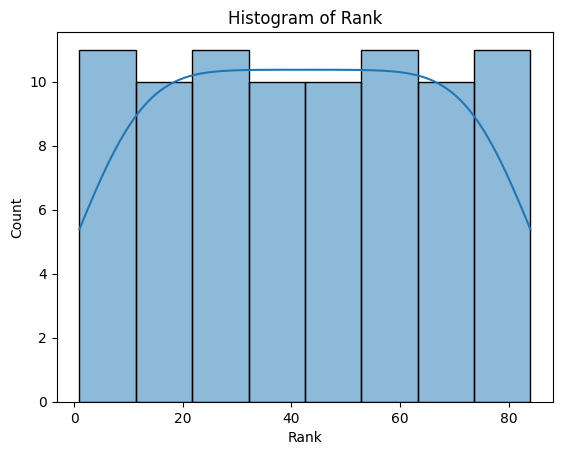

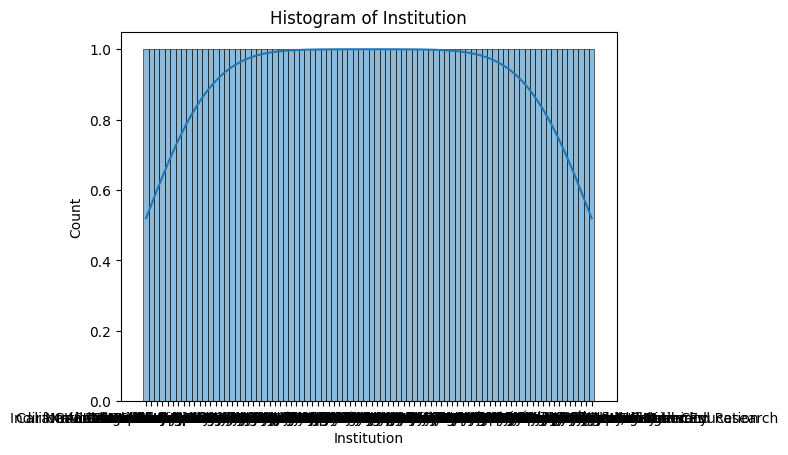

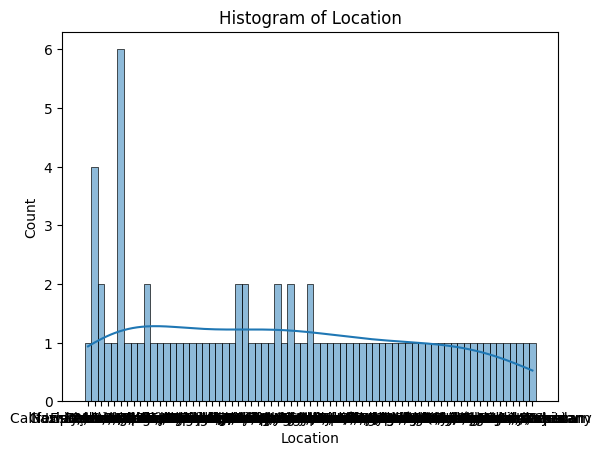

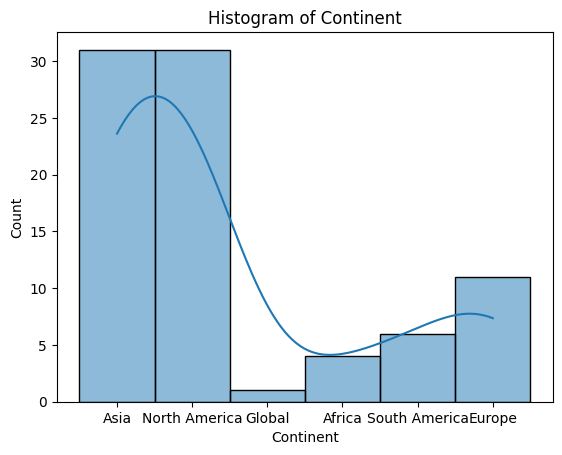

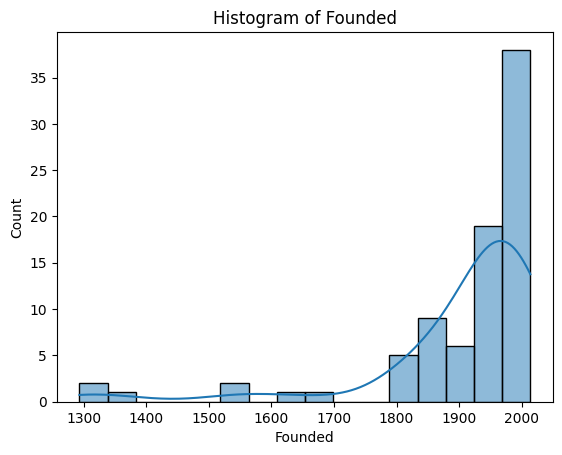

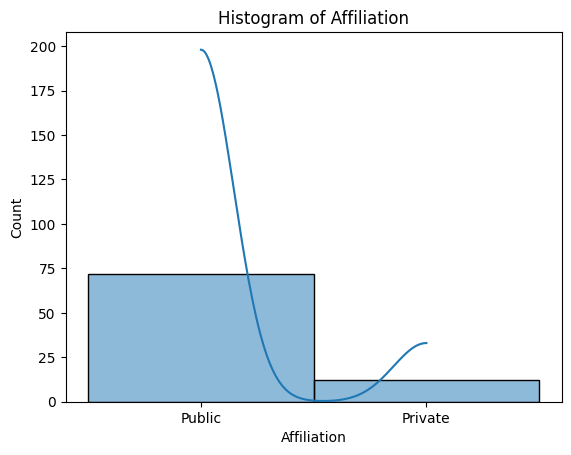

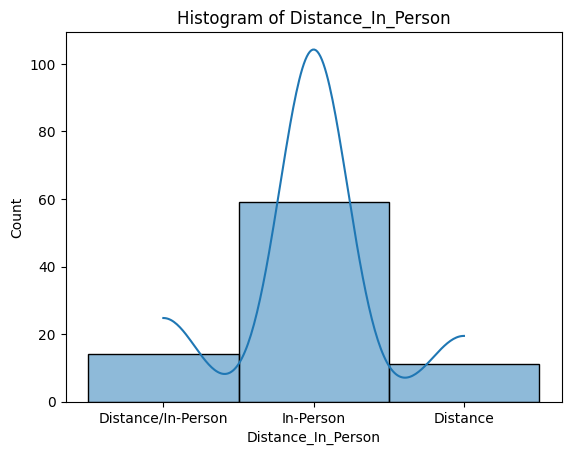

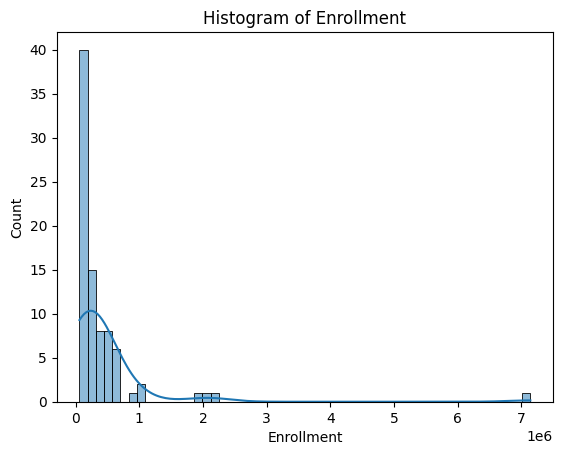

In [25]:
for i in df.columns:
    plt.title(f'Histogram of {i}')
    sns.histplot(data=df,x=i,kde=True)
    plt.show()

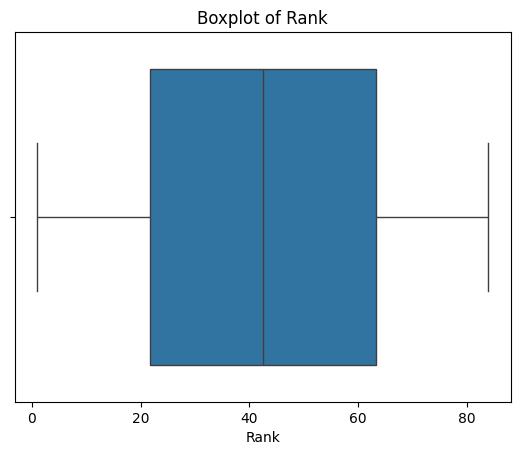

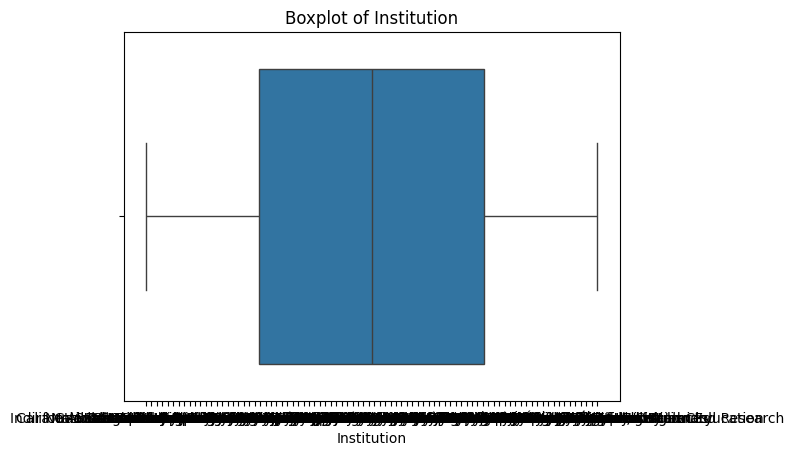

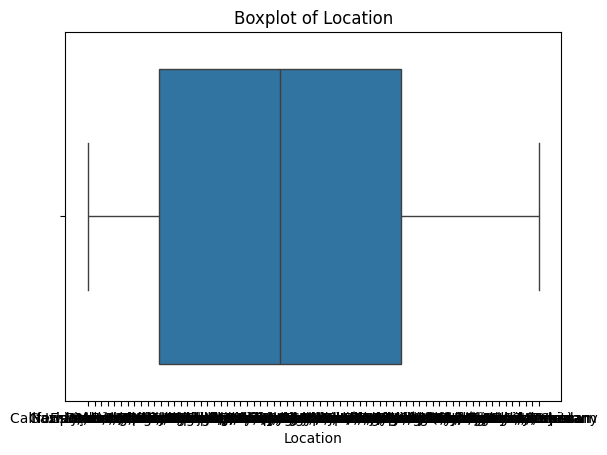

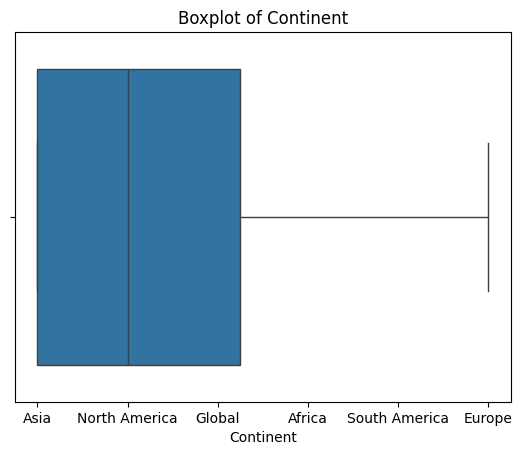

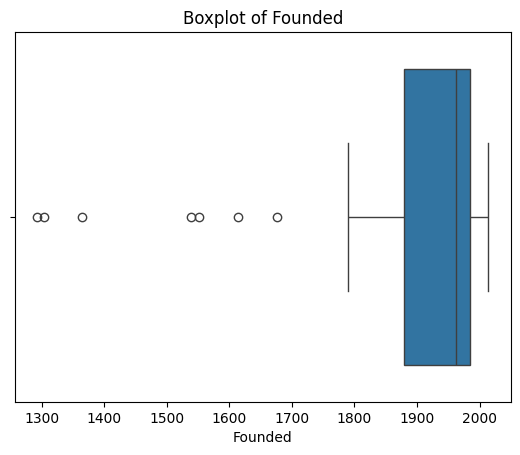

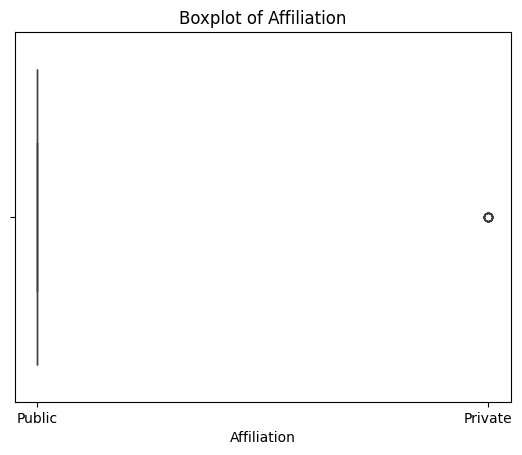

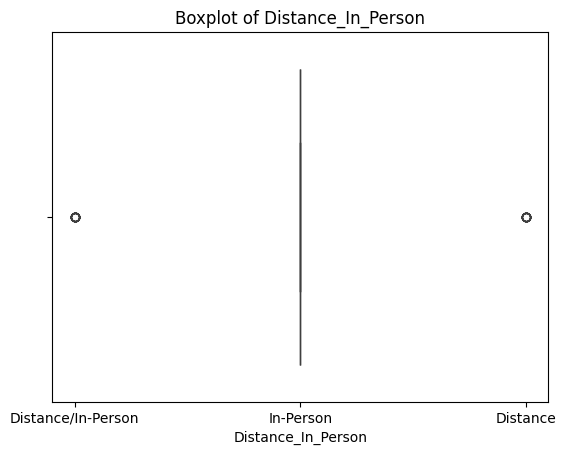

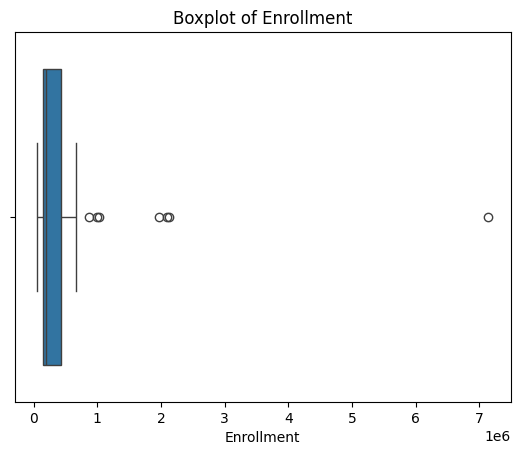

In [26]:
for i in df.columns:
    plt.title(f'Boxplot of {i}')
    sns.boxplot(data=df,x=i)
    plt.show()

In [27]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


In [28]:
df.describe()

,Rank,Founded,Enrollment
count,84.000000,84.000000,8.400000e+01
mean,42.500000,1905.857143,4.267342e+05
std,24.392622,147.444590,8.396098e+05
min,1.000000,1293.000000,6.000000e+04
25%,21.750000,1879.750000,1.405810e+05
50%,42.500000,1963.000000,1.957835e+05
75%,63.250000,1984.250000,4.275000e+05
max,84.000000,2014.000000,7.140000e+06


In [29]:
df.corr(numeric_only=True)

,Rank,Founded,Enrollment
Rank,1.000000,-0.270593,-0.496521
Founded,-0.270593,1.000000,0.144547
Enrollment,-0.496521,0.144547,1.000000


In [30]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


# KPI's

In [31]:
## Total Institutes
pd.read_sql_query('Select COUNT(Institution) AS Total_Institutes from [Top_Universities]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_4720\151336912.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select COUNT(Institution) AS Total_Institutes from [Top_Universities]',con=connection)


,Total_Institutes
0,84


In [32]:
### AVG Enrollment ###
pd.read_sql_query('Select AVG(Enrollment) AS Average_Enrollment from [Top_Universities]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_4720\1080510406.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql_query('Select AVG(Enrollment) AS Average_Enrollment from [Top_Universities]',con=connection)


,Average_Enrollment
0,426734


# Analysis

# Top 10 Institutes by Enrollment

In [33]:
Top_10_Institute_By_Enrollment = pd.read_sql_query(' Select TOP 10 Institution,Enrollment from [Top_Universities]',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_4720\4035481612.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Top_10_Institute_By_Enrollment = pd.read_sql_query(' Select TOP 10 Institution,Enrollment from [Top_Universities]',con=connection)


In [34]:
Top_10_Institute_By_Enrollment

,Institution,Enrollment
0,Indira Gandhi National Open University,7140000
1,California Community Colleges System,2133846
2,"National University, Bangladesh",2097182
3,Anadolu University,1974343
4,Allama Iqbal Open University,1027000
5,Islamic Azad University,1000000
6,"Laureate Education, Inc.",875000
7,Bangladesh Open University,650000
8,Universitas Terbuka,646467
9,National Technological Institute of Mexico,620000


In [35]:
Institute = Top_10_Institute_By_Enrollment['Institution']
Enrollment = Top_10_Institute_By_Enrollment['Enrollment']

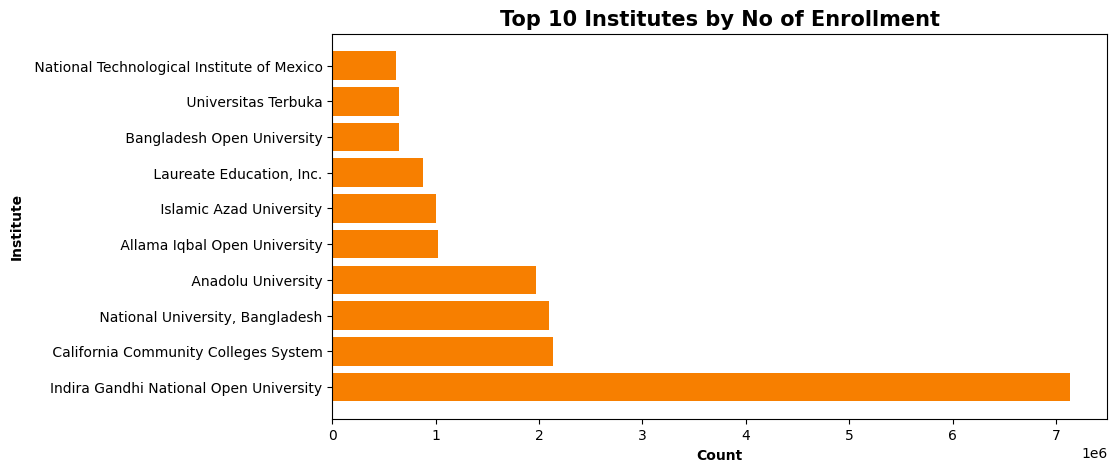

In [36]:
plt.figure(figsize=(10,5))
plt.title('Top 10 Institutes by No of Enrollment',fontdict={'fontweight':'bold','fontsize':15})
plt.xlabel('Count',fontdict={'fontweight':'bold'})
plt.ylabel('Institute',fontdict={'fontweight':'bold'})
plt.barh(Institute,Enrollment,color=['#f77f00'])
plt.show()

In [37]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


# No of Institutes By Continent

In [38]:
No_OF_Institutes_By_Enrollment = df.groupby('Continent').agg(No_of_Institutes=('Institution','count')).sort_values(by='No_of_Institutes').reset_index()

In [39]:
No_OF_Institutes_By_Enrollment

,Continent,No_of_Institutes
0,Global,1
1,Africa,4
2,South America,6
3,Europe,11
4,Asia,31
5,North America,31


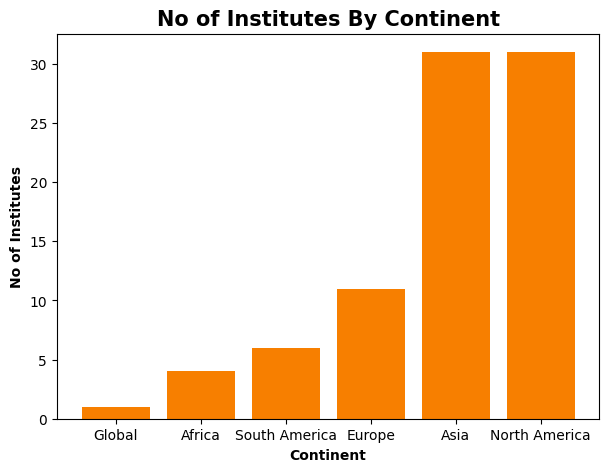

In [40]:
plt.figure(figsize=(7,5))
plt.title('No of Institutes By Continent',fontdict={'fontweight':'bold','fontsize':15})
plt.xlabel('Continent',fontdict={'fontweight':'bold'})
plt.ylabel('No of Institutes',fontdict={'fontweight':'bold'})
plt.bar(No_OF_Institutes_By_Enrollment['Continent'],No_OF_Institutes_By_Enrollment['No_of_Institutes'],color=['#f77f00'])
plt.show()

In [41]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


# Institutes By Affiliation

In [42]:
NO_Of_Institutes_By_Affiliation = pd.read_sql_query(' Select Affiliation,Count(Institution) No_of_Institutes from [Top_Universities] group by Affiliation',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_4720\4256664294.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  NO_Of_Institutes_By_Affiliation = pd.read_sql_query(' Select Affiliation,Count(Institution) No_of_Institutes from [Top_Universities] group by Affiliation',con=connection)


In [43]:
NO_Of_Institutes_By_Affiliation

,Affiliation,No_of_Institutes
0,Private,12
1,Public,72


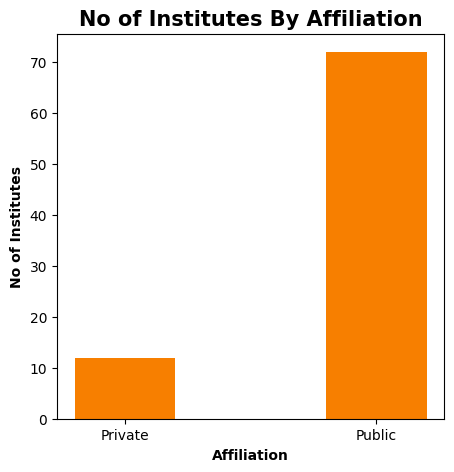

In [44]:
plt.figure(figsize=(5,5))
plt.title('No of Institutes By Affiliation',fontdict={'fontweight':'bold','fontsize':15})
plt.xlabel('Affiliation',fontdict={'fontweight':'bold'})
plt.ylabel('No of Institutes',fontdict={'fontweight':'bold'})
plt.bar(NO_Of_Institutes_By_Affiliation['Affiliation'],NO_Of_Institutes_By_Affiliation['No_of_Institutes'],color=['#f77f00'],width=0.4)
plt.show()

In [45]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_In_Person,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


In [46]:
df.rename(columns={'Distance_In_Person': 'Distance_Type'},inplace=True)

In [47]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_Type,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


# No of Institutes by Distance Type

In [48]:
No_Of_Institutes_By_Distance_Type = df.groupby('Distance_Type').agg(No_Of_Institutes=('Institution','count')).reset_index()

In [49]:
No_Of_Institutes_By_Distance_Type

,Distance_Type,No_Of_Institutes
0,Distance,11
1,Distance/In-Person,14
2,In-Person,59


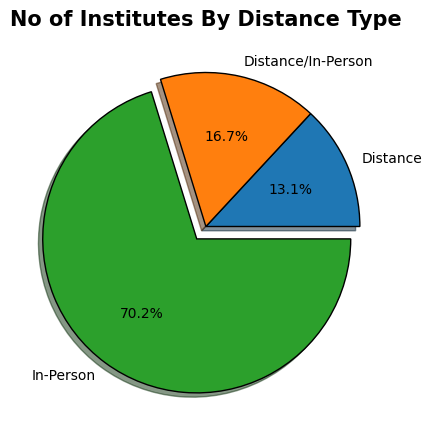

In [50]:
explode=[0,0,0.1]
plt.figure(figsize=(5,5))
plt.title('No of Institutes By Distance Type',fontdict={'fontweight':'bold','fontsize':15})
plt.pie(No_Of_Institutes_By_Distance_Type['No_Of_Institutes'],labels=No_Of_Institutes_By_Distance_Type['Distance_Type'].values,autopct='%1.1f%%',shadow=True,wedgeprops={'edgecolor':'black'},explode=explode)
plt.show()

In [51]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_Type,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


# Average Enrollment By Affiliation

In [52]:
Average_Enrollment_By_Affiliation = pd.read_sql_query(' Select Affiliation,AVG(Enrollment) AVG_Enrollment from [Top_Universities] group by Affiliation',con=connection)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_4720\1032475232.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Average_Enrollment_By_Affiliation = pd.read_sql_query(' Select Affiliation,AVG(Enrollment) AVG_Enrollment from [Top_Universities] group by Affiliation',con=connection)


In [53]:
Average_Enrollment_By_Affiliation

,Affiliation,AVG_Enrollment
0,Private,281998
1,Public,450856


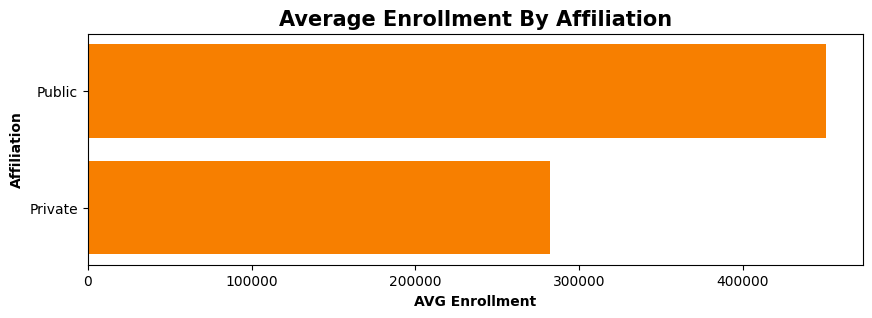

In [54]:
plt.figure(figsize=(10,3))
plt.title('Average Enrollment By Affiliation',fontdict={'fontweight':'bold','fontsize':15})
plt.xlabel('AVG Enrollment',fontdict={'fontweight':'bold'})
plt.ylabel('Affiliation',fontdict={'fontweight':'bold'})
plt.barh(Average_Enrollment_By_Affiliation['Affiliation'],Average_Enrollment_By_Affiliation['AVG_Enrollment'],color=['#f77f00'])
plt.show()

# Average Enrollment By Founded

In [55]:
Average_Enrollment_By_Founded = df.groupby('Founded').agg({'Enrollment':'mean'}).reset_index()

In [56]:
Average_Enrollment_By_Founded

,Founded,Enrollment
0,1293,83000.0
1,1303,147000.0
2,1365,91715.0
3,1538,170530.0
4,1551,356530.0
...,...,...
63,2002,307500.0
64,2007,478000.0
65,2009,126000.0
66,2012,80000.0


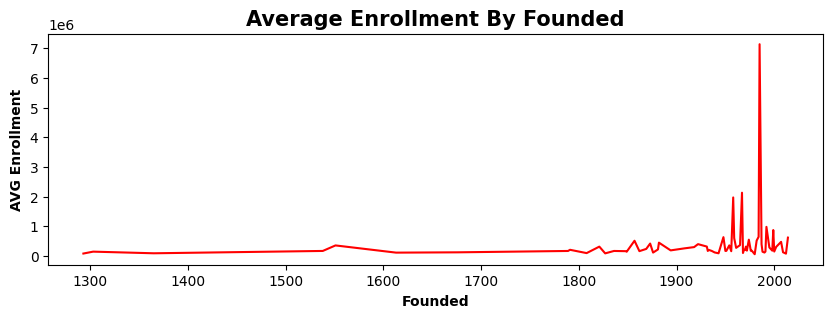

In [62]:
plt.figure(figsize=(10,3))
plt.title('Average Enrollment By Founded',fontdict={'fontweight':'bold','fontsize':15})
plt.xlabel('Founded',fontdict={'fontweight':'bold'})
plt.ylabel('AVG Enrollment',fontdict={'fontweight':'bold'})
plt.plot(Average_Enrollment_By_Founded['Founded'],Average_Enrollment_By_Founded['Enrollment'],color='red')
plt.show()

In [58]:
df.head()

,Rank,Institution,Location,Continent,Founded,Affiliation,Distance_Type,Enrollment
0,1,Indira Gandhi National Open University,"New Delhi, India",Asia,1985,Public,Distance/In-Person,7140000
1,2,California Community Colleges System,"California, United States",North America,1967,Public,In-Person,2133846
2,3,"National University, Bangladesh","Gazipur, Bangladesh",Asia,1992,Public,In-Person,2097182
3,4,Anadolu University,"Eskişehir, Turkey",Asia,1958,Public,Distance/In-Person,1974343
4,5,Allama Iqbal Open University,"Islamabad, Pakistan",Asia,1974,Public,Distance/In-Person,1027000


# Average Enrollment By Distance Type

In [59]:
Average_Enrollment_By_Distance_Type = df.groupby('Distance_Type').agg({'Enrollment':'mean'}).reset_index()

In [60]:
Average_Enrollment_By_Distance_Type

,Distance_Type,Enrollment
0,Distance,309543.272727
1,Distance/In-Person,911252.785714
2,In-Person,333612.915254


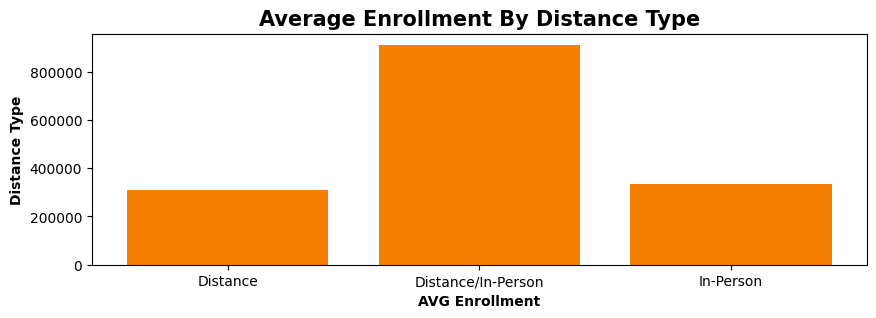

In [61]:
plt.figure(figsize=(10,3))
plt.title('Average Enrollment By Distance Type',fontdict={'fontweight':'bold','fontsize':15})
plt.xlabel('AVG Enrollment',fontdict={'fontweight':'bold'})
plt.ylabel('Distance Type',fontdict={'fontweight':'bold'})
plt.bar(Average_Enrollment_By_Distance_Type['Distance_Type'],Average_Enrollment_By_Distance_Type['Enrollment'],color=['#f77f00'])
plt.show()

In [65]:
df.to_csv(r'E:\Data Analyst Roadmap\Google Data Analytics Certificate Course\Different Analysis\Top Largest Universities By Enrollment\Data Cleaning and Analysis using Python and SQL\cleaned_Data.csv',index=False)

In [66]:
df.to_excel(r'E:\Data Analyst Roadmap\Google Data Analytics Certificate Course\Different Analysis\Top Largest Universities By Enrollment\Data Cleaning and Analysis using Python and SQL\cleaned_Data.xlsx',index=False)